<a href="https://colab.research.google.com/github/RajBhatta67/measles-rubella-project/blob/main/Measles_and_Rubles_Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Checkpoint #1


In [30]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
# Load the datasets from GitHub raw URLs
yearly_df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/measles_rubella/measles_rubella_yearly.csv')
monthly_df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/measles_rubella/measles_rubella_monthly.csv')


In [2]:
# Rename verbose columns to something workable
yearly_df= yearly_df.rename(columns = {'measles_incidence_rate_per_1000000_total_population': 'measles_incidence_rate',
    'rubella_incidence_rate_per_1000000_total_population': 'rubella_incidence_rate',
    'annualized_population_most_recent_year_only': 'annualized_population',
    'discarded_non_measles_rubella_cases_per_100000_total_population': 'discarded_rate',
    'total_suspected_measles_rubella_cases': 'total_suspected',
    'discarded_cases': 'discarded_total', })

In [3]:
yearly_number_columns = [
    'total_population',
    'annualized_population',
    'total_suspected',
    'measles_total',
    'measles_lab_confirmed',
    'measles_epi_linked',
    'measles_clinical',
    'measles_incidence_rate',
    'rubella_total',
    'rubella_lab_confirmed',
    'rubella_epi_linked',
    'rubella_clinical',
    'rubella_incidence_rate',
    'discarded_total',
    'discarded_rate',
]

# go through each one and force it to be a number
# if a value can't be converted it becomes NaN (blank)
for col in yearly_number_columns:
    if col in yearly_df.columns:
        yearly_df[col] = pd.to_numeric(yearly_df[col], errors='coerce')
# same thing for the monthly file
monthly_number_columns = [
    'measles_suspect',
    'measles_clinical',
    'measles_epi_linked',
    'measles_lab_confirmed',
    'measles_total',
    'rubella_clinical',
    'rubella_epi_linked',
    'rubella_lab_confirmed',
    'rubella_total',
    'discarded',
]

for col in monthly_number_columns:
    if col in monthly_df.columns:
        monthly_df[col] = pd.to_numeric(monthly_df[col], errors='coerce')

In [4]:
# year and month must be whole numbers
yearly_df['year']  = yearly_df['year'].astype(int)
monthly_df['year'] = monthly_df['year'].astype(int)
monthly_df['month'] = monthly_df['month'].astype(int)

In [5]:
# Check for missing values
yearly_df.isna().sum()

,0
region,0
country,0
iso3,0
year,0
total_population,0
annualized_population,0
total_suspected,87
measles_total,0
measles_lab_confirmed,0
measles_epi_linked,0


In [6]:
#Amount of data missing
missing_pct = yearly_df.isna().mean() * 100
print(missing_pct.round(1))

region                     0.0
country                    0.0
iso3                       0.0
year                       0.0
total_population           0.0
annualized_population      0.0
total_suspected            3.7
measles_total              0.0
measles_lab_confirmed      0.0
measles_epi_linked         0.0
measles_clinical           0.0
measles_incidence_rate     0.0
rubella_total              0.0
rubella_lab_confirmed      0.0
rubella_epi_linked         0.0
rubella_clinical           0.0
rubella_incidence_rate     0.0
discarded_total            3.7
discarded_rate            17.1
dtype: float64


In [7]:
print("\nrows before removing 2025:", len(yearly_df))
yearly_df  = yearly_df[yearly_df['year'] < 2025].copy()
monthly_df = monthly_df[monthly_df['year'] < 2025].copy()
print("rows after removing 2025 :", len(yearly_df))


rows before removing 2025: 2380
rows after removing 2025 : 2212


In [8]:
duplicates = yearly_df.duplicated(subset=['country', 'year'])
print("\nduplicate country-year rows:", duplicates.sum())



duplicate country-year rows: 0


In [9]:
# strip any extra whitespace from region names
# so 'AFRO ' and 'AFRO' don't get counted as different groups
yearly_df['region'] = yearly_df['region'].str.strip()

In [10]:
print(yearly_df['region'].value_counts())

region
EURO     632
AFRO     560
WPRO     319
AMRO     299
EMRO     264
SEARO    138
Name: count, dtype: int64


In [11]:
def get_period(year):
  if 2012 <= year <= 2019:
    return 'Pre-COVID (2012-2019)'
  elif year in [2020, 2021]:
    return 'COVID (2020-2021)'
  else:
    return 'Post-COVID (2022-2024)'

yearly_df['period'] = yearly_df['year'].apply(get_period)

In [12]:

# I will use this to color-code charts by time period

yearly_df['in_core_window']     = (yearly_df['year'] >= 2012) & (yearly_df['year'] <= 2019)
yearly_df['is_covid_disrupted'] = yearly_df['year'].isin([2020, 2021])
yearly_df['in_surge_window']    = (yearly_df['year'] >= 2022) & (yearly_df['year'] <= 2024)

In [13]:
MIN_CASES = 20

yearly_df['measles_lab_share']      = yearly_df['measles_lab_confirmed'] / yearly_df['measles_total'].replace(0, np.nan)

yearly_df['measles_clinical_share'] = yearly_df['measles_clinical']      / yearly_df['measles_total'].replace(0, np.nan)

yearly_df['rubella_lab_share']      = yearly_df['rubella_lab_confirmed'] / yearly_df['rubella_total'].replace(0, np.nan)

yearly_df['rubella_clinical_share'] = yearly_df['rubella_clinical']      / yearly_df['rubella_total'].replace(0, np.nan)

bad_measles = yearly_df['measles_lab_share'] > 1
bad_rubella = yearly_df['rubella_lab_share'] > 1
print("\nimpossible measles lab_share values (> 1):", bad_measles.sum())
print("impossible rubella lab_share values (> 1):", bad_rubella.sum())

# remove impossible values

yearly_df.loc[bad_measles, 'measles_lab_share'] = np.nan
yearly_df.loc[bad_rubella, 'rubella_lab_share'] = np.nan

# flag rows where we have enough cases to trust the ratio
yearly_df['measles_denom_ok'] = yearly_df['measles_total'] >= MIN_CASES
yearly_df['rubella_denom_ok']  = yearly_df['rubella_total']  >= MIN_CASES

# log incidence for plotting (fixes skew from large outbreaks)
yearly_df['measles_log_incidence'] = np.log1p(yearly_df['measles_incidence_rate'])
yearly_df['rubella_log_incidence']  = np.log1p(yearly_df['rubella_incidence_rate'])

print("\nmeasles lab_share (core window, >= 20 cases):")
core_m = yearly_df[yearly_df['in_core_window'] & yearly_df['measles_denom_ok']]
print(core_m['measles_lab_share'].describe().round(3))

print("\nrubella lab_share (core window, >= 20 cases):")
core_r = yearly_df[yearly_df['in_core_window'] & yearly_df['rubella_denom_ok']]
print(core_r['rubella_lab_share'].describe().round(3))


impossible measles lab_share values (> 1): 0
impossible rubella lab_share values (> 1): 0

measles lab_share (core window, >= 20 cases):
count    727.000
mean       0.609
std        0.340
min        0.000
25%        0.294
50%        0.688
75%        0.938
max        1.000
Name: measles_lab_share, dtype: float64

rubella lab_share (core window, >= 20 cases):
count    353.000
mean       0.860
std        0.300
min        0.000
25%        0.944
50%        1.000
75%        1.000
max        1.000
Name: rubella_lab_share, dtype: float64


In [14]:
yearly_df.loc[yearly_df['measles_denom_ok'], 'measles_incidence_rate'].describe()


,measles_incidence_rate
count,1120.000000
mean,98.702161
std,477.554153
min,0.150000
25%,4.865000
50%,16.915000
75%,47.670000
max,9439.260000


In [15]:
yearly_df = yearly_df.sort_values(['country', 'year']).reset_index(drop=True)

# each country's own typical measles incidence
yearly_df['country_median_incidence'] = (
    yearly_df
    .groupby('country')['measles_incidence_rate']
    .transform('median')
)

# outbreak = more than 2x their own normal AND at least 20 cases
yearly_df['measles_outbreak_year'] = (
    (yearly_df['measles_incidence_rate'] > 2.0 * yearly_df['country_median_incidence']) &
    (yearly_df['measles_total'] >= MIN_CASES) &
    (yearly_df['measles_incidence_rate']> 47.67)
)

print("outbreak years flagged:", yearly_df['measles_outbreak_year'].sum(), "out of",
      yearly_df['measles_denom_ok'].sum(), "denom_ok rows  -> rate:",
      round(yearly_df.loc[yearly_df['measles_denom_ok'],'measles_outbreak_year'].mean()*100,1), "%")

outbreak years flagged: 218 out of 1120 denom_ok rows  -> rate: 19.5 %


In [16]:
# Build the measles rows
measles_rows = yearly_df[[
    'country', 'iso3', 'region', 'year', 'period',
    'total_population', 'in_core_window',
    'in_surge_window', 'is_covid_disrupted'
]].copy()
measles_rows['disease']        = 'measles'
measles_rows['total_cases']    = yearly_df['measles_total'].values
measles_rows['lab_confirmed']  = yearly_df['measles_lab_confirmed'].values
measles_rows['epi_linked']     = yearly_df['measles_epi_linked'].values
measles_rows['clinical']       = yearly_df['measles_clinical'].values
measles_rows['incidence_rate'] = yearly_df['measles_incidence_rate'].values
measles_rows['log_incidence']  = yearly_df['measles_log_incidence'].values
measles_rows['lab_share']      = yearly_df['measles_lab_share'].values
measles_rows['clinical_share'] = yearly_df['measles_clinical_share'].values
measles_rows['denom_ok']       = yearly_df['measles_denom_ok'].values
measles_rows['outbreak_year']  = yearly_df['measles_outbreak_year'].values

# rubella rows
rubella_rows = yearly_df[[
    'country', 'iso3', 'region', 'year', 'period',
    'total_population', 'in_core_window',
    'in_surge_window', 'is_covid_disrupted'
]].copy()
rubella_rows['disease']        = 'rubella'
rubella_rows['total_cases']    = yearly_df['rubella_total'].values
rubella_rows['lab_confirmed']  = yearly_df['rubella_lab_confirmed'].values
rubella_rows['epi_linked']     = yearly_df['rubella_epi_linked'].values
rubella_rows['clinical']       = yearly_df['rubella_clinical'].values
rubella_rows['incidence_rate'] = yearly_df['rubella_incidence_rate'].values
rubella_rows['log_incidence']  = yearly_df['rubella_log_incidence'].values
rubella_rows['lab_share']      = yearly_df['rubella_lab_share'].values
rubella_rows['clinical_share'] = yearly_df['rubella_clinical_share'].values
rubella_rows['denom_ok']       = yearly_df['rubella_denom_ok'].values
rubella_rows['outbreak_year']  = np.nan

tidy_df = pd.concat([measles_rows, rubella_rows], ignore_index=True)
tidy_df = tidy_df.sort_values(['country', 'year', 'disease']).reset_index(drop=True)

print("\ntidy_df shape:", tidy_df.shape)
tidy_df[['country', 'year', 'disease', 'total_cases', 'lab_share', 'period']].head(6)



tidy_df shape: (4424, 20)


,country,year,disease,total_cases,lab_share,period
0,Afghanistan,2012,measles,2791,0.949122,Pre-COVID (2012-2019)
1,Afghanistan,2012,rubella,88,0.988636,Pre-COVID (2012-2019)
2,Afghanistan,2013,measles,430,0.960465,Pre-COVID (2012-2019)
3,Afghanistan,2013,rubella,20,1.000000,Pre-COVID (2012-2019)
4,Afghanistan,2014,measles,552,0.891304,Pre-COVID (2012-2019)
5,Afghanistan,2014,rubella,46,1.000000,Pre-COVID (2012-2019)


In [17]:
# how many months out of 12 does each country actually report? # rubella monthly data turns out to be very sparse # this is why we will do the main analysis on yearly data
monthly_df['measles_reported'] = monthly_df['measles_total'].notna()
monthly_df['rubella_reported']  = monthly_df['rubella_total'].notna()

completeness = monthly_df.groupby(['country', 'year']).agg(
    measles_months_reported = ('measles_reported', 'sum'),
    rubella_months_reported = ('rubella_reported', 'sum'),
).reset_index()

completeness['measles_completeness'] = completeness['measles_months_reported'] / 12
completeness['rubella_completeness']  = completeness['rubella_months_reported'] / 12

In [18]:

yearly_df = yearly_df.merge(
    completeness[['country', 'year', 'measles_completeness', 'rubella_completeness']],
    on=['country', 'year'],
    how='left'
)

# join onto tidy_df too
tidy_df = tidy_df.merge(
    completeness[['country', 'year', 'measles_completeness', 'rubella_completeness']],
    on=['country', 'year'],
    how='left'
)

# for tidy_df, each row only needs the completeness for its own disease
# so create one unified completeness column
tidy_df['reporting_completeness'] = tidy_df.apply(
    lambda row: row['measles_completeness'] if row['disease'] == 'measles'
    else row['rubella_completeness'],
    axis=1
)

The research question(being finalized): To what extent does surveillance quality differ between measles and rubella, and does that quality drop when case counts surge?


Checkpoint #2


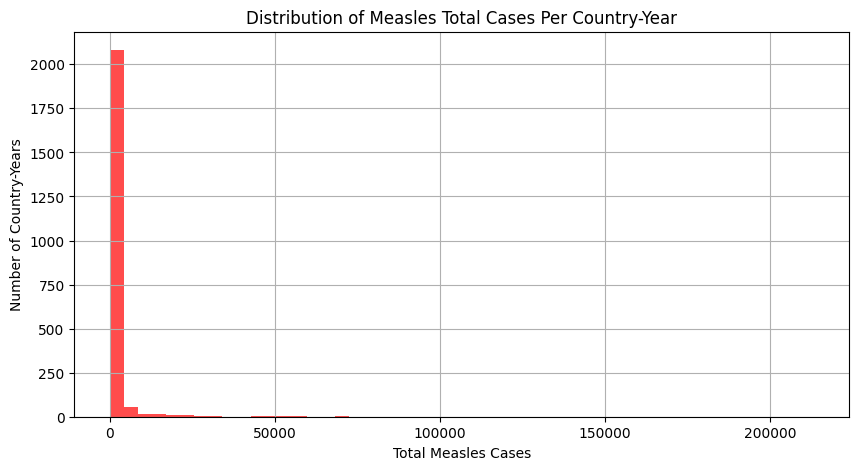

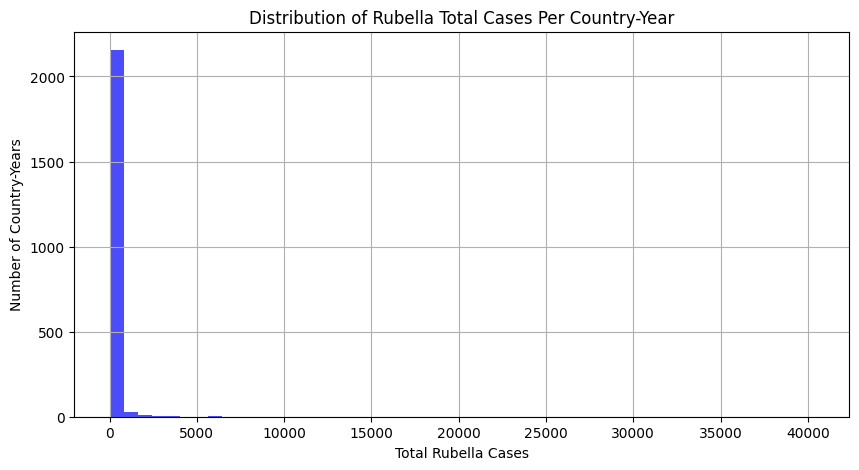

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(yearly_df['measles_total'].dropna(), bins=50, color='red', alpha=0.7)
plt.title('Distribution of Measles Total Cases Per Country-Year')
plt.xlabel('Total Measles Cases')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()

# --- histogram: rubella total cases ---
plt.figure(figsize=(10, 5))
plt.hist(yearly_df['rubella_total'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Rubella Total Cases Per Country-Year')
plt.xlabel('Total Rubella Cases')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()


--- global cases by year ---
    year  measles_total  rubella_total
0   2012         110579          61378
1   2013         178006          67408
2   2014         290888          35207
3   2015         247474          22418
4   2016         180015          18679
5   2017         168190          10712
6   2018         276157          17045
7   2019         541401          47766
8   2020          93840           7501
9   2021          59619           7410
10  2022         174340          12620
11  2023         321889          10421
12  2024         359534          23572


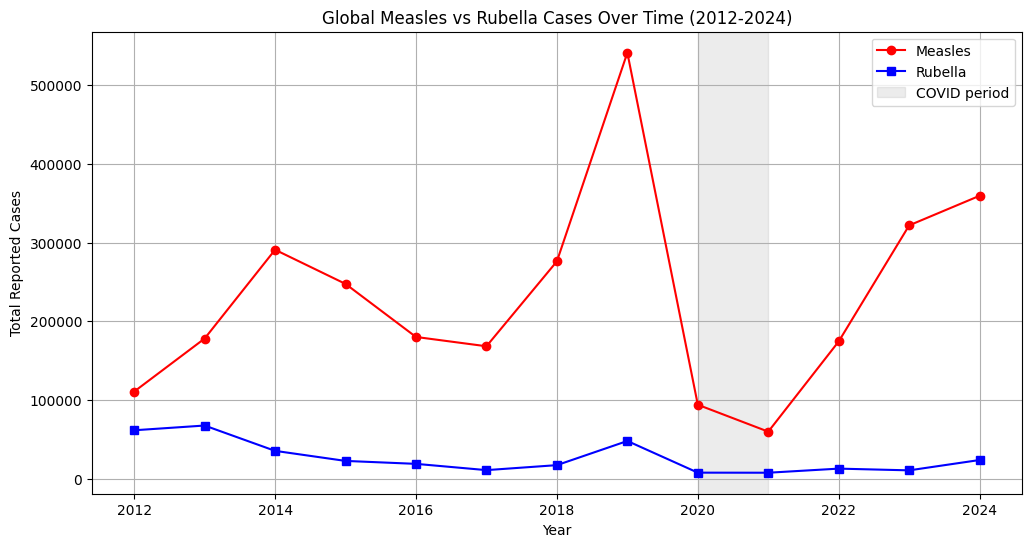

In [20]:
global_by_year = yearly_df.groupby('year').agg(
    measles_total = ('measles_total', 'sum'),
    rubella_total = ('rubella_total', 'sum'),
).reset_index()

print("\n--- global cases by year ---")
print(global_by_year.to_string())

# line plot: raw case counts
plt.figure(figsize=(12, 6))
plt.plot(global_by_year['year'], global_by_year['measles_total'],
         color='red', marker='o', label='Measles')
plt.plot(global_by_year['year'], global_by_year['rubella_total'],
         color='blue', marker='s', label='Rubella')
plt.axvspan(2020, 2021, alpha=0.15, color='grey', label='COVID period')
plt.title('Global Measles vs Rubella Cases Over Time (2012-2024)')
plt.xlabel('Year')
plt.ylabel('Total Reported Cases')
plt.legend()
plt.grid()
plt.show()


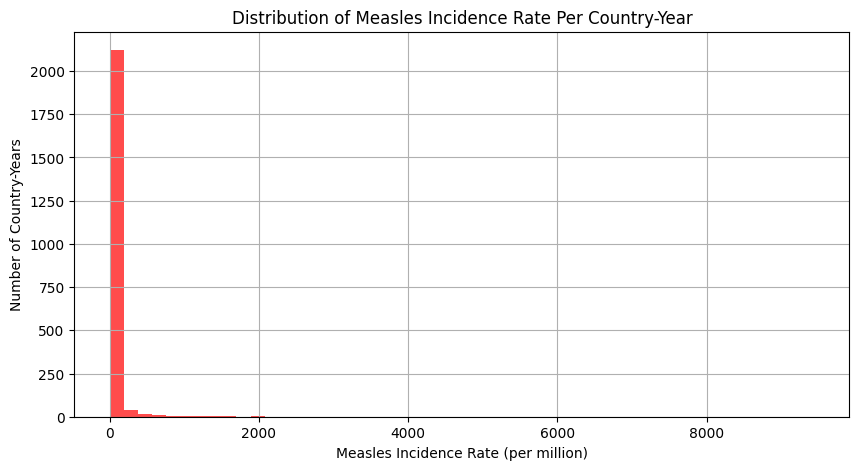

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(yearly_df['measles_incidence_rate'].dropna(), bins=50, color='red', alpha=0.7)
plt.title('Distribution of Measles Incidence Rate Per Country-Year')
plt.xlabel('Measles Incidence Rate (per million)')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()

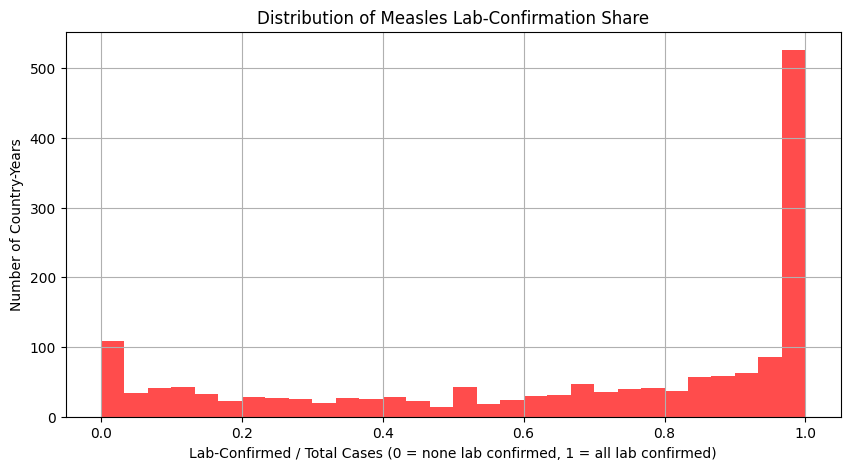

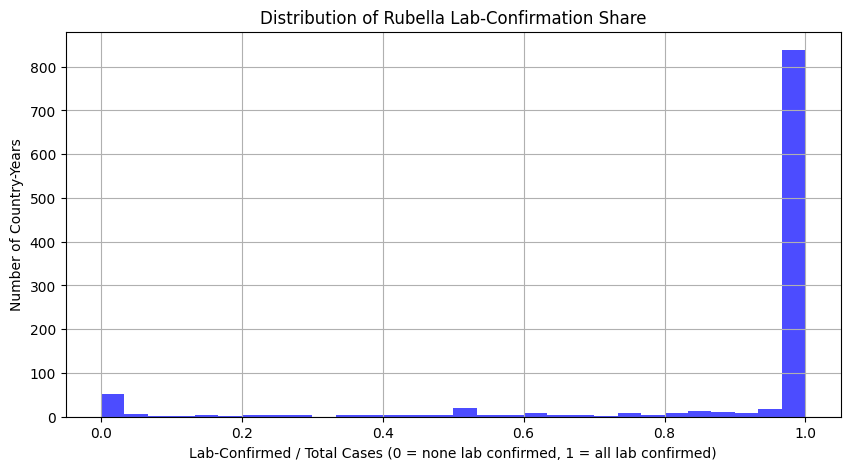

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(yearly_df['measles_lab_share'].dropna(), bins=30, color='red', alpha=0.7)
plt.title('Distribution of Measles Lab-Confirmation Share')
plt.xlabel('Lab-Confirmed / Total Cases (0 = none lab confirmed, 1 = all lab confirmed)')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(yearly_df['rubella_lab_share'].dropna(), bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Rubella Lab-Confirmation Share')
plt.xlabel('Lab-Confirmed / Total Cases (0 = none lab confirmed, 1 = all lab confirmed)')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()


--- WHO regions ---
region
EURO     632
AFRO     560
WPRO     319
AMRO     299
EMRO     264
SEARO    138
Name: count, dtype: int64

--- time periods ---
period
Pre-COVID (2012-2019)     1356
Post-COVID (2022-2024)     528
COVID (2020-2021)          328
Name: count, dtype: int64

--- diseases in tidy_df ---
disease
measles    2212
rubella    2212
Name: count, dtype: int64


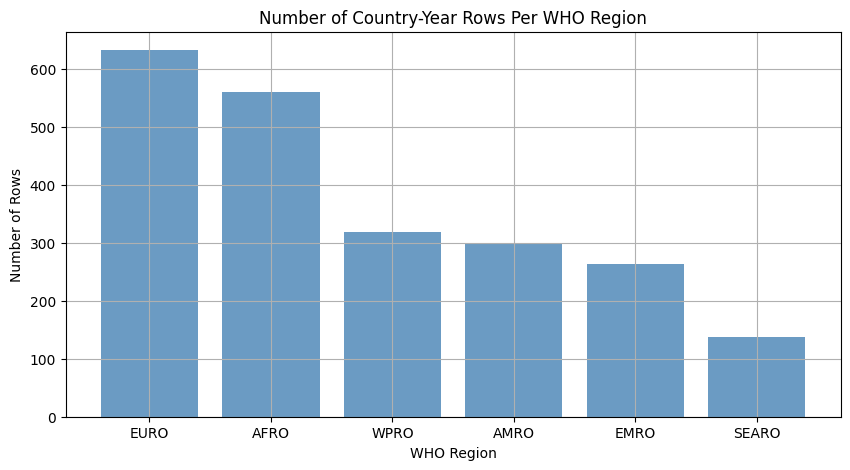

In [23]:
print("\n--- WHO regions ---")
print(yearly_df['region'].value_counts())

print("\n--- time periods ---")
print(yearly_df['period'].value_counts())

print("\n--- diseases in tidy_df ---")
print(tidy_df['disease'].value_counts())

# bar chart of country-years per region
region_counts = yearly_df['region'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(region_counts.index, region_counts.values, color='steelblue', alpha=0.8)
plt.title('Number of Country-Year Rows Per WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Number of Rows')
plt.grid()
plt.show()

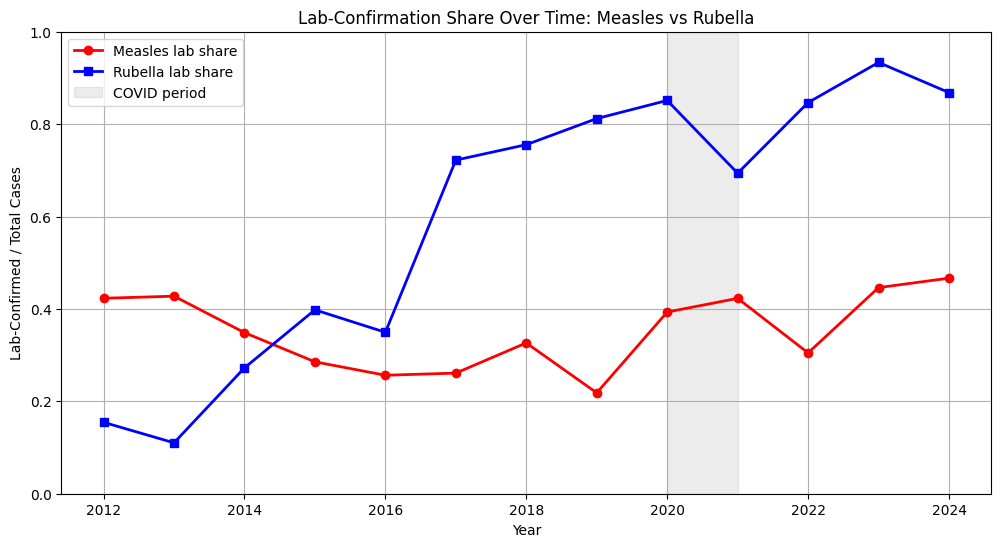

In [24]:

global_shares = yearly_df.groupby('year').agg(
    measles_lab   = ('measles_lab_confirmed', 'sum'),
    measles_total = ('measles_total', 'sum'),
    rubella_lab   = ('rubella_lab_confirmed', 'sum'),
    rubella_total = ('rubella_total', 'sum'),
).reset_index()

global_shares['measles_lab_share'] = global_shares['measles_lab'] / global_shares['measles_total']
global_shares['rubella_lab_share'] = global_shares['rubella_lab'] / global_shares['rubella_total']

plt.figure(figsize=(12, 6))
plt.plot(global_shares['year'], global_shares['measles_lab_share'],
         color='red', marker='o', lw=2, label='Measles lab share')
plt.plot(global_shares['year'], global_shares['rubella_lab_share'],
         color='blue', marker='s', lw=2, label='Rubella lab share')
plt.axvspan(2020, 2021, alpha=0.15, color='grey', label='COVID period')
plt.title('Lab-Confirmation Share Over Time: Measles vs Rubella')
plt.xlabel('Year')
plt.ylabel('Lab-Confirmed / Total Cases')
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()


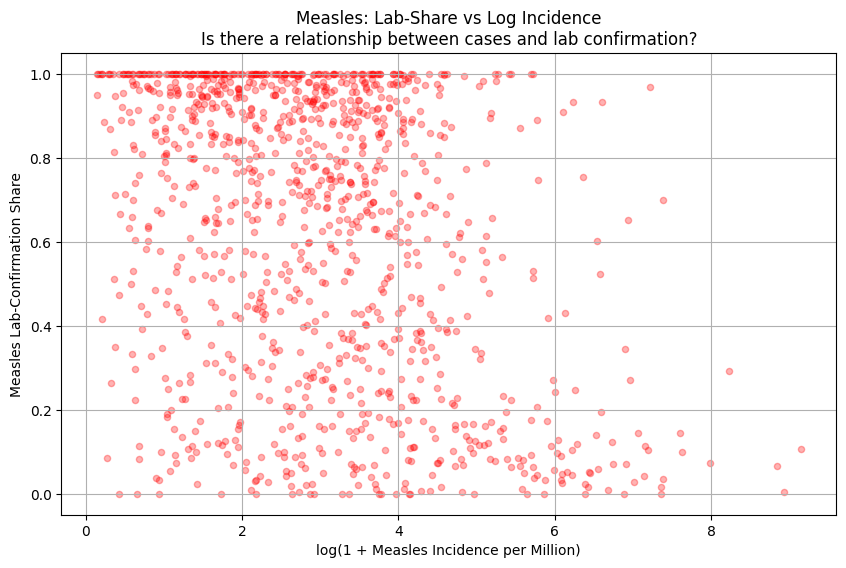

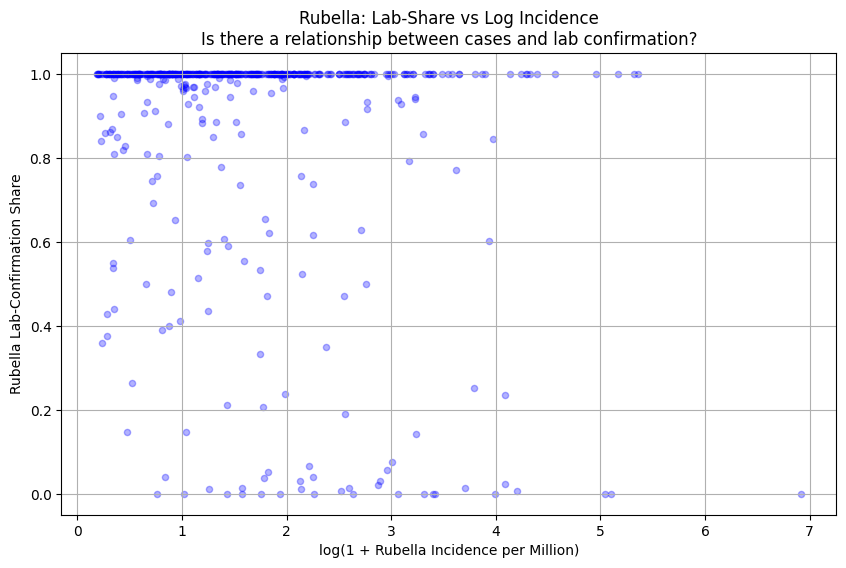

In [25]:
valid_m = yearly_df[yearly_df['measles_denom_ok']].dropna(
    subset=['measles_log_incidence', 'measles_lab_share']
)

plt.figure(figsize=(10, 6))
plt.scatter(valid_m['measles_log_incidence'],
            valid_m['measles_lab_share'],
            alpha=0.3, s=20, color='red')
plt.title('Measles: Lab-Share vs Log Incidence\nIs there a relationship between cases and lab confirmation?')
plt.xlabel('log(1 + Measles Incidence per Million)')
plt.ylabel('Measles Lab-Confirmation Share')
plt.ylim(-0.05, 1.05)
plt.grid()
plt.show()


# --- 4c. rubella lab share vs rubella incidence ---
valid_r = yearly_df[yearly_df['rubella_denom_ok']].dropna(
    subset=['rubella_log_incidence', 'rubella_lab_share']
)

plt.figure(figsize=(10, 6))
plt.scatter(valid_r['rubella_log_incidence'],
            valid_r['rubella_lab_share'],
            alpha=0.3, s=20, color='blue')
plt.title('Rubella: Lab-Share vs Log Incidence\nIs there a relationship between cases and lab confirmation?')
plt.xlabel('log(1 + Rubella Incidence per Million)')
plt.ylabel('Rubella Lab-Confirmation Share')
plt.ylim(-0.05, 1.05)
plt.grid()
plt.show()

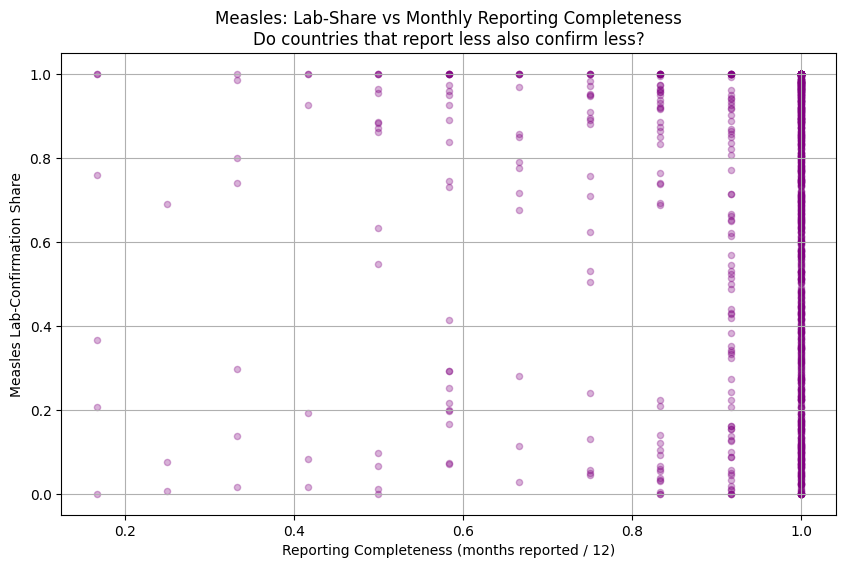

In [26]:
valid_comp = yearly_df[yearly_df['measles_denom_ok']].dropna(
    subset=['measles_completeness', 'measles_lab_share']
)

plt.figure(figsize=(10, 6))
plt.scatter(valid_comp['measles_completeness'],
            valid_comp['measles_lab_share'],
            alpha=0.3, s=20, color='purple')
plt.title('Measles: Lab-Share vs Monthly Reporting Completeness\nDo countries that report less also confirm less?')
plt.xlabel('Reporting Completeness (months reported / 12)')
plt.ylabel('Measles Lab-Confirmation Share')
plt.ylim(-0.05, 1.05)
plt.grid()
plt.show()

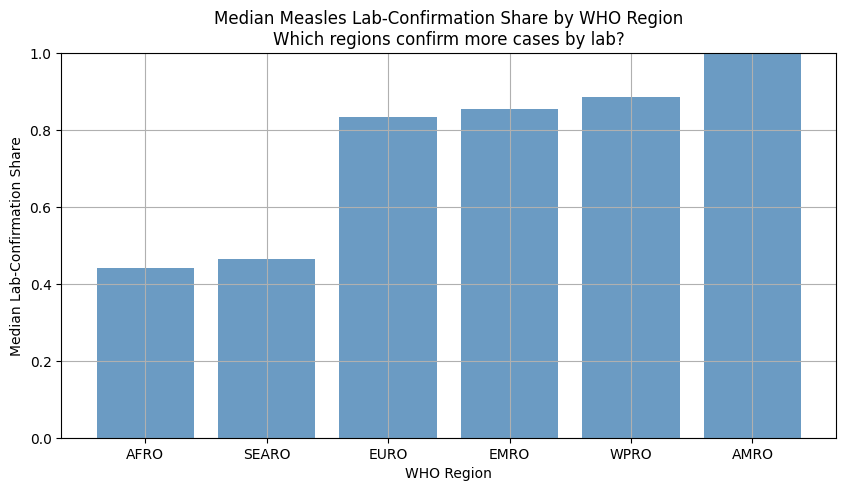

median measles lab share by region:
region
AFRO     0.442
SEARO    0.465
EURO     0.832
EMRO     0.853
WPRO     0.886
AMRO     1.000
Name: measles_lab_share, dtype: float64


In [27]:
# which regions have higher or lower lab confirmation rates?

region_lab = (
    yearly_df[yearly_df['measles_denom_ok']]
    .groupby('region')['measles_lab_share']
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 5))
plt.bar(region_lab.index, region_lab.values, color='steelblue', alpha=0.8)
plt.title('Median Measles Lab-Confirmation Share by WHO Region\nWhich regions confirm more cases by lab?')
plt.xlabel('WHO Region')
plt.ylabel('Median Lab-Confirmation Share')
plt.ylim(0, 1)
plt.grid()
plt.show()

print("median measles lab share by region:")
print(region_lab.round(3))

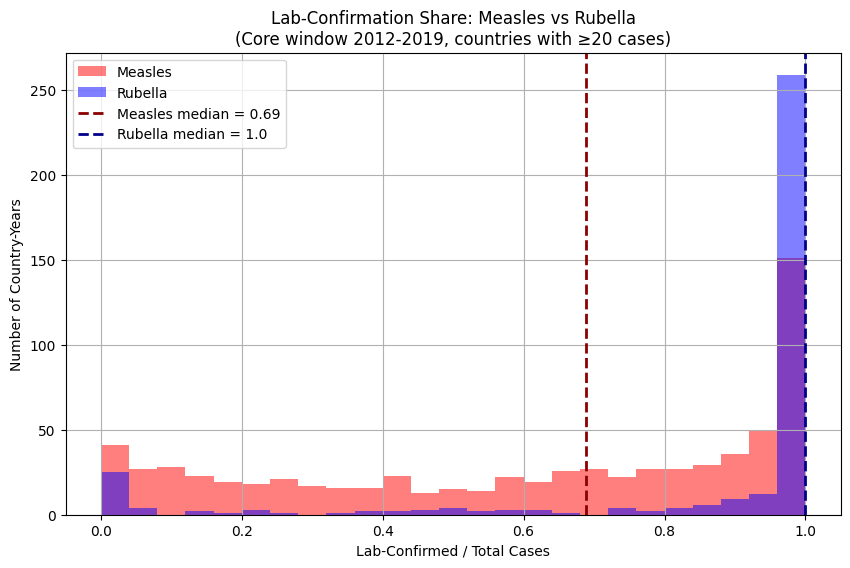

In [28]:
measles_core = yearly_df[
    yearly_df['in_core_window'] & yearly_df['measles_denom_ok']
]['measles_lab_share'].dropna()

rubella_core = yearly_df[
    yearly_df['in_core_window'] & yearly_df['rubella_denom_ok']
]['rubella_lab_share'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(measles_core, bins=25, color='red',  alpha=0.5, label='Measles')
plt.hist(rubella_core, bins=25, color='blue', alpha=0.5, label='Rubella')
plt.axvline(measles_core.median(), color='darkred',  ls='--', lw=2,
            label='Measles median = ' + str(round(measles_core.median(), 2)))
plt.axvline(rubella_core.median(), color='darkblue', ls='--', lw=2,
            label='Rubella median = ' + str(round(rubella_core.median(), 2)))
plt.title('Lab-Confirmation Share: Measles vs Rubella\n(Core window 2012-2019, countries with ≥20 cases)')
plt.xlabel('Lab-Confirmed / Total Cases')
plt.ylabel('Number of Country-Years')
plt.legend()
plt.grid()
plt.show()

In [29]:
print("\nstandard deviation of key numeric variables:")
print(yearly_df[yearly_number_columns].std().round(3).sort_values(ascending=False))

# variation in lab share by region
print("\nlab share variation across regions (std dev:")
region_std = (
    yearly_df[yearly_df['measles_denom_ok']]
    .groupby('region')['measles_lab_share']
    .std()
    .sort_values(ascending=False)
)
print(region_std.round(3))

# variation in lab share by period
print("\nlab share variation across time periods (mean:")
period_lab = (
    yearly_df[yearly_df['measles_denom_ok']]
    .groupby('period')['measles_lab_share']
    .mean()
)
print(period_lab.round(3))


standard deviation of key numeric variables:
total_population          1.498426e+08
annualized_population     1.498426e+08
total_suspected           1.012596e+04
measles_total             7.202817e+03
measles_epi_linked        4.854545e+03
discarded_total           4.596351e+03
measles_clinical          3.542881e+03
measles_lab_confirmed     2.308291e+03
rubella_total             1.530710e+03
rubella_clinical          1.303781e+03
rubella_lab_confirmed     6.541420e+02
measles_incidence_rate    3.432770e+02
rubella_epi_linked        2.174830e+02
rubella_incidence_rate    2.421100e+01
discarded_rate            7.057000e+00
dtype: float64

lab share variation across regions (std dev:
region
WPRO     0.341
AFRO     0.337
EMRO     0.335
SEARO    0.284
EURO     0.269
AMRO     0.072
Name: measles_lab_share, dtype: float64

lab share variation across time periods (mean:
period
COVID (2020-2021)         0.582
Post-COVID (2022-2024)    0.672
Pre-COVID (2012-2019)     0.609
Name: measles_lab_sh

Checkpoint #3

In [33]:
both_core = yearly_df[
    yearly_df['measles_denom_ok'] &
    yearly_df['rubella_denom_ok'] &
    yearly_df['in_core_window']
].dropna(subset=['measles_lab_share', 'rubella_lab_share']).copy()

t_stat, p_val = stats.ttest_rel(
    both_core['rubella_lab_share'],
    both_core['measles_lab_share']
)

print("\n--- H1: paired t-test results ---")
print("n (country-years):", len(both_core))
print("t-statistic      :", round(t_stat, 3))
print("p-value          :", f"{p_val:.2e}")

# interpret the result
alpha = 0.05
if p_val < alpha:
    print("\nresult: SIGNIFICANT (p <", alpha, ")")
    print("we reject the null hypothesis")
    print("rubella lab share IS significantly higher than measles lab share")
    print("H1 is SUPPORTED")
else:
    print("\nresult: NOT SIGNIFICANT (p >=", alpha, ")")
    print("we fail to reject the null hypothesis")
    print("H1 is NOT SUPPORTED")


--- H1: paired t-test results ---
n (country-years): 307
t-statistic      : 15.669
p-value          : 4.91e-41

result: SIGNIFICANT (p < 0.05 )
we reject the null hypothesis
rubella lab share IS significantly higher than measles lab share
H1 is SUPPORTED
